In [1]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 59.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00


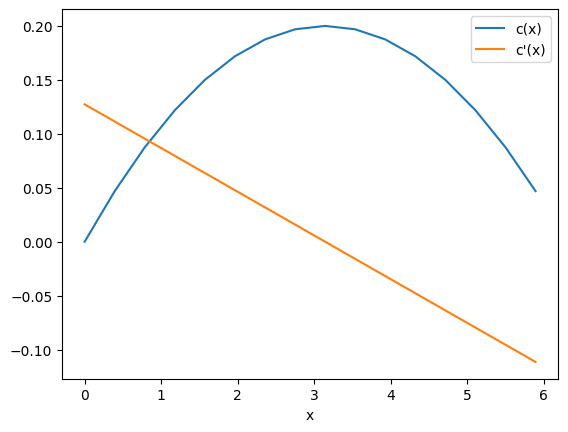

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 4

D = 0.1
N = 2**n_qubits
L = 2 * np.pi               
t = 0.4   
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 


plt.plot(x, c, label='c(x)')
plt.plot(x, cx, label='c\'(x)')
plt.xlabel('x')
plt.legend()

In [ ]:
from lchs import lchs , spectral_diff_adv

# Initial State: Gaussian centered in the middle
sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)

ts = [0.5, 1.0, 1.5, 2.0]

plt.figure()
plt.plot(x, state, 'ko', markersize=4)
plt.plot(x, state, 'k-', label='$t=0$',)
errs = []

for t in ts:
    lchs_state, success_prob = lchs(n_qubits, t, cx, c, D, L, init_state=state, r_steps=100,   useFixedJ=True, fixed_J=128)
    exact = spectral_diff_adv(n_qubits, t, cx, c, D, L, np.zeros_like(c), init_state=state)
    errs.append(np.linalg.norm(np.real(lchs_state) - np.real(exact)))

    line, = plt.plot(x, np.real(lchs_state), 'o', markersize=4)
    color = line.get_color()
    plt.plot(x, exact, '--', color=color, label=f'$t={t:.1f}$', )
plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.legend(loc='best', fontsize=14)
#plt.savefig('./figures/lcu_kernel_lchs_diffusion.pdf', bbox_inches='tight')
plt.show()

plt.figure() 
plt.semilogy(ts, errs, 'o-')
plt.xlabel('$t$ ')
plt.ylabel('$|||\\psi\\rangle- |\\psi_{ex}\\rangle ||$')
#plt.savefig('./figures/diff_error_vs_time.pdf', bbox_inches='tight')
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_8379/1898995026.py:24: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')


Applying shift of 0.0557 to ensure positive semidefiniteness.
